RETAIL SALES ANALYSIS & BUSINESS INSIGHTS

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_excel(r"C:\Users\anilh\Downloads\Blinkit pbi\BlinkIT Grocery Data.xlsx")

In [4]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


                                                DATA CLEANING




In this section, we cleaned the dataset by handling missing values, correcting column names, and preparing the data for analysis.

In [5]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [6]:
#Changing Coloumns name into lower and instead of space we adding "_" beacuse easy to access the coloumn

df.columns=df.columns.str.lower().str.replace(' ','_')

In [7]:
df.columns

Index(['item_fat_content', 'item_identifier', 'item_type',
       'outlet_establishment_year', 'outlet_identifier',
       'outlet_location_type', 'outlet_size', 'outlet_type', 'item_visibility',
       'item_weight', 'sales', 'rating'],
      dtype='object')

In [8]:
df['item_fat_content'].unique()

df['item_fat_content']=df['item_fat_content'].replace({'reg':'Regular','LF':'Low Fat','low fat':'Low Fat'})


In [9]:
df['item_fat_content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_fat_content           8523 non-null   object 
 1   item_identifier            8523 non-null   object 
 2   item_type                  8523 non-null   object 
 3   outlet_establishment_year  8523 non-null   int64  
 4   outlet_identifier          8523 non-null   object 
 5   outlet_location_type       8523 non-null   object 
 6   outlet_size                8523 non-null   object 
 7   outlet_type                8523 non-null   object 
 8   item_visibility            8523 non-null   float64
 9   item_weight                7060 non-null   float64
 10  sales                      8523 non-null   float64
 11  rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [11]:
df.isnull().sum()

# finding duplicates ,found duplicates in item_weight

item_fat_content                0
item_identifier                 0
item_type                       0
outlet_establishment_year       0
outlet_identifier               0
outlet_location_type            0
outlet_size                     0
outlet_type                     0
item_visibility                 0
item_weight                  1463
sales                           0
rating                          0
dtype: int64

In [12]:
df['item_weight']=df.groupby('item_type')['item_weight'].transform(lambda x : x.fillna(x.median()))

# filling the null values with median category wise

In [13]:
df.describe()


,outlet_establishment_year,item_visibility,item_weight,sales,rating
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.813390,140.992783,3.965857
std,3.189396,0.051598,4.241384,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,9.310000,93.826500,4.000000
50%,2016.000000,0.053931,12.850000,143.012800,4.000000
75%,2018.000000,0.094585,16.000000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['item_identifier'].nunique()

1559

In [16]:
df['outlet_identifier'].nunique()


10

In [80]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['sales'] < lower) | (df['sales'] > upper)]

print(outliers.shape)


##FINDING OUTLIERS

(0, 12)


                                             Exploratory Data Analysis(EDA)

In [20]:
pivot = df.groupby(['outlet_location_type', 'outlet_type'])['sales'].sum().unstack()
pivot

outlet_type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
outlet_location_type,,,,
Tier 1,73807.5824,262590.2296,NaN,NaN
Tier 2,NaN,393150.6476,NaN,NaN
Tier 3,78131.5666,131809.0156,131477.7764,130714.6746


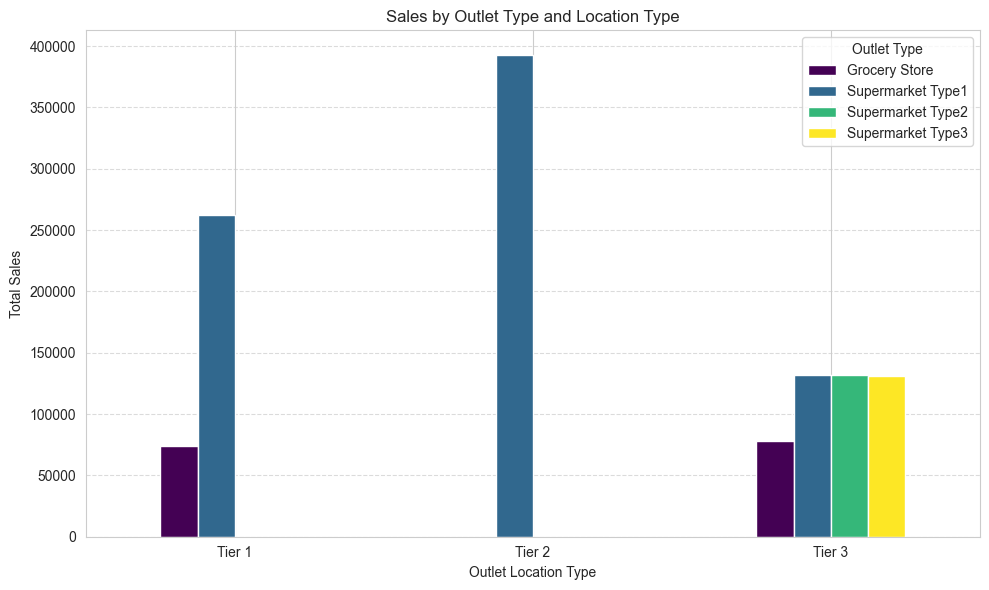

In [78]:
pivot.plot(kind='bar', figsize=(10,6),colormap='viridis')

plt.title("Sales by Outlet Type and Location Type")
plt.xlabel("Outlet Location Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.legend(title="Outlet Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Before These graph we got clarity TYPE1 getting high sales but we need to find location,from these graph we got that clarity also ,from TIER2 location SUPERMARKET TYPE1 getting highest sales

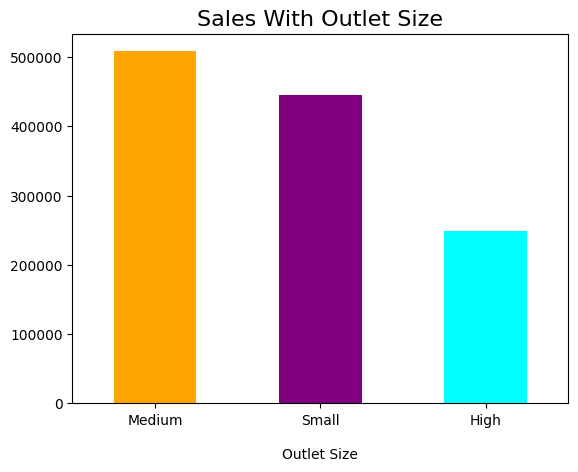

In [ ]:
Size=df.groupby('outlet_size')['sales'].sum().sort_values(ascending=False)
Size.plot(kind='bar',color=['orange','purple','cyan'])


plt.title('Sales With Outlet Size',fontsize=16)
plt.xlabel("Outlet Size", labelpad=15)
plt.xticks(rotation=0)
plt.show()


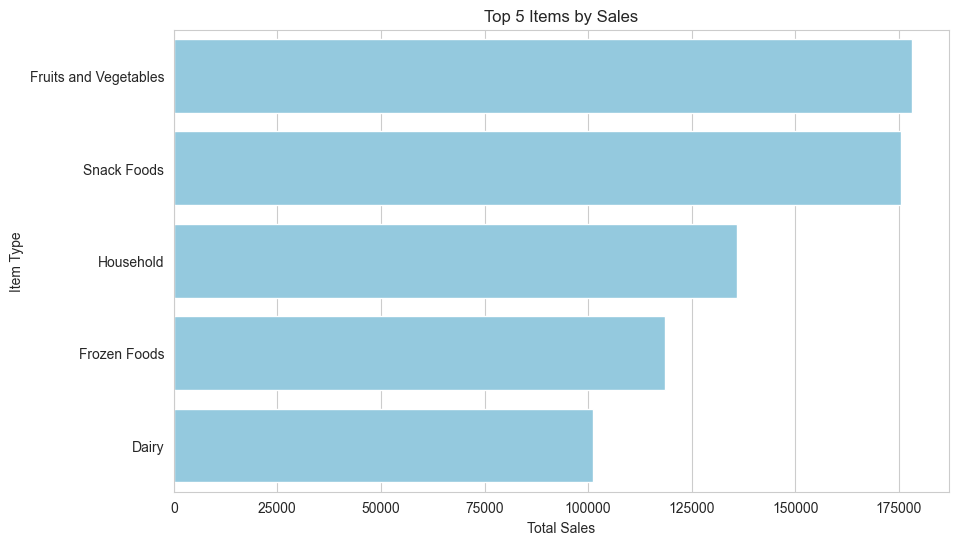

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group data
item_sales = df.groupby('item_type')['sales'].sum().sort_values(ascending=False)

#Top 5 items_type

top5 = item_sales.head(5)

plt.figure(figsize=(10,6))
sns.barplot(x=top5.values, y=top5.index,color="skyblue")



plt.title("Top 5 Items by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Item Type")

plt.show()

C:\Users\anilh\AppData\Local\Temp\ipykernel_3392\701701768.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=outlet_sales.values, y=outlet_sales.index, palette='Set2')


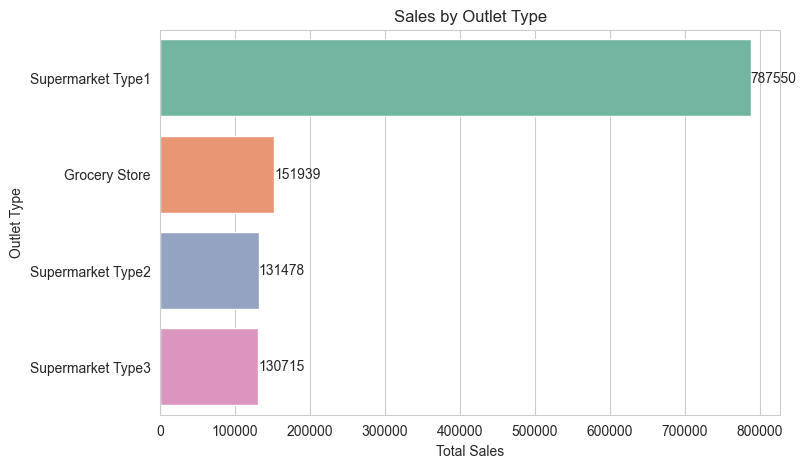

In [69]:
plt.figure(figsize=(8,5))

outlet_sales = df.groupby('outlet_type')['sales']\
                 .sum().sort_values(ascending=False)

ax = sns.barplot(x=outlet_sales.values, y=outlet_sales.index, palette='Set2')


for i, v in enumerate(outlet_sales.values):
    ax.text(v, i, f"{v:.0f}", va='center')


plt.title("Sales by Outlet Type")
plt.xlabel("Total Sales")
plt.ylabel("Outlet Type")

plt.show()

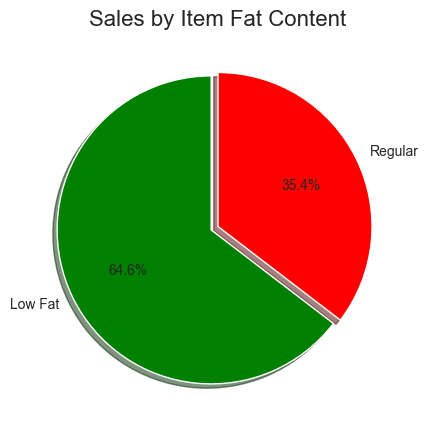

In [75]:
grouped=df.groupby('item_fat_content')['sales'].sum()

plt.figure(figsize=(5,5))
grouped.plot(kind='pie',autopct='%1.1f%%',colors=['green','red'],startangle=90,shadow=True,
                explode=[0.05,0])
plt.title('Sales by Item Fat Content',fontsize=16)
plt.ylabel('')

plt.show()


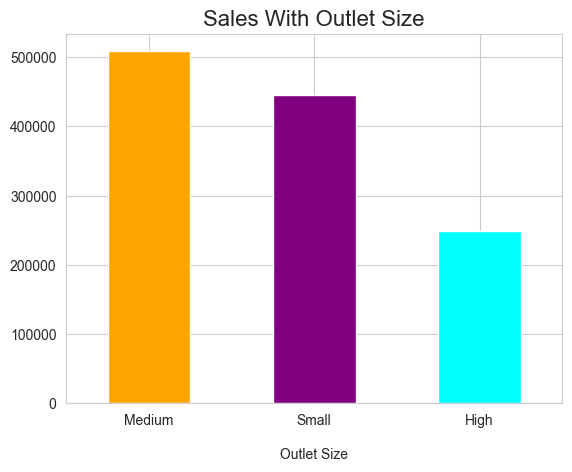

In [79]:

sns.set_style('whitegrid')
Size=df.groupby('outlet_size')['sales'].sum().sort_values(ascending=False)
Size.plot(kind='bar',color=['orange','purple','cyan'])


plt.title('Sales With Outlet Size',fontsize=16)
plt.xlabel("Outlet Size", labelpad=15)
plt.xticks(rotation=0)
plt.show()


                                                CONCLUSION 


The analysis reveals that certain product categories and outlet types significantly contribute to overall sales. Expanding high-performing categories and focusing on Tier 3 locations can help improve business growth.

                                                KEY INSIGHTS

- Fruits and Vegetables are the top-selling item types.
- Supermarket Type1 generates the highest revenue. Mainly in Tier 2 location
- Tier 3 locations show strong sales performance.
- Low-fat products contribute more to total sales.

                                                REQUIREMENTS

Increase more type 1 supermarkets in Tier2 locations.
Fruits and vegetables are keep in stocks .
Focus mainly in healthyfoods.
Invest more on Medium size outlets.